In [16]:
print("Fake News Detection Project Started")


Fake News Detection Project Started


In [17]:
import pandas as pd
import numpy as np


In [18]:
fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")


In [19]:
fake_df["label"] = 0   # Fake news
true_df["label"] = 1   # Real news


In [20]:
df = pd.concat([fake_df, true_df], axis=0)
df.head()


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [21]:
df = df.sample(frac=1).reset_index(drop=True)


In [22]:
df.shape


(44898, 5)

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


In [24]:
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
ps = PorterStemmer()
stop_words = set(stopwords.words("english"))


In [26]:
def clean_text(text):
    text = text.lower()                      # lowercase
    text = re.sub('[^a-z]', ' ', text)       # remove numbers & punctuation
    words = text.split()                     # tokenization
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)


In [27]:
df.columns


Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [28]:
df["clean_text"] = df["text"].apply(clean_text)


In [29]:
df[["text", "clean_text"]].head()


,text,clean_text
0,Vice President Joe Biden has nothing but glowi...,vice presid joe biden noth glow prais democrat...
1,NEW YORK (Reuters) - Donald Trump likes to boa...,new york reuter donald trump like boast suppor...
2,WASHINGTON (Reuters) - President Barack Obama ...,washington reuter presid barack obama monday l...
3,Trump commented about it during the reception:...,trump comment recept hope start bipartisan eve...
4,Read anything Stephen Henderson has written ov...,read anyth stephen henderson written past year...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [31]:
vectorizer = TfidfVectorizer(max_features=5000)


In [32]:
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]


In [33]:
X.shape


(44898, 5000)

In [34]:
from sklearn.model_selection import train_test_split


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
X_train.shape
X_test.shape


(8980, 5000)

In [37]:
from sklearn.linear_model import LogisticRegression


In [38]:
model = LogisticRegression(max_iter=1000)


In [39]:
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_pred = model.predict(X_test)


In [41]:
y_pred = model.predict(X_test)


In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


Accuracy: 0.9857461024498887
[[4550   78]
 [  50 4302]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4628
           1       0.98      0.99      0.99      4352

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [44]:
import pickle


In [45]:
with open("../model/fake_news_model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("../model/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)
with open("../model/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)


In [46]:
import pickle

model = pickle.load(open("../model/fake_news_model.pkl", "rb"))
vectorizer = pickle.load(open("../model/tfidf_vectorizer.pkl", "rb"))


In [47]:
def predict_news(news_text):
    cleaned = clean_text(news_text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)
    return "REAL NEWS 🟢" if prediction[0] == 1 else "FAKE NEWS 🔴"


In [48]:
news = """
Government announces new education policy to improve digital learning across the country.
"""

print(predict_news(news))


FAKE NEWS 🔴


In [49]:
news = """Scientists discover a cure for the common cold, promising an end to seasonal illnesses.
"""
print(predict_news(news))

FAKE NEWS 🔴


In [50]:
news = """Celebrity couple announces their divorce, shocking fans worldwide.
"""
print(predict_news(news))

FAKE NEWS 🔴


In [51]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier

In [52]:
nb = MultinomialNB()
pa = PassiveAggressiveClassifier()

nb.fit(X_train, y_train)
pa.fit(X_train, y_train)

c:\Users\hp\OneDrive\Desktop\Fake News Detection\venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Aggressiveness parameter for the passive-agressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [53]:
print("Logistic:", accuracy_score(y_test, model.predict(X_test)))
print("Naive Bayes:", accuracy_score(y_test, nb.predict(X_test)))
print("Passive Aggressive:", accuracy_score(y_test, pa.predict(X_test)))

Logistic: 0.9857461024498887
Naive Bayes: 0.9267260579064588
Passive Aggressive: 0.993652561247216


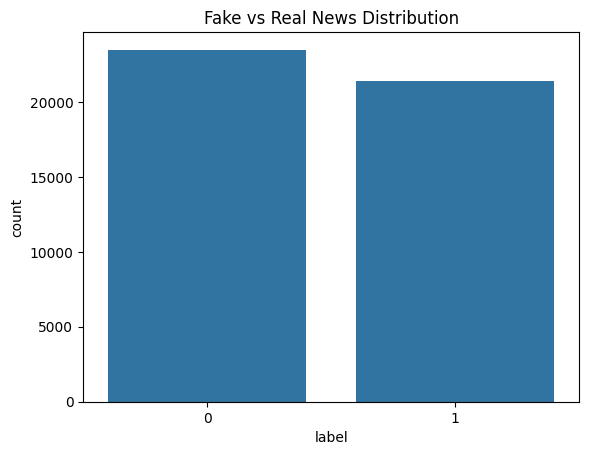

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["label"])
plt.title("Fake vs Real News Distribution")
plt.show()

In [55]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_fake = sorted(zip(coef, feature_names))[:20]
top_real = sorted(zip(coef, feature_names), reverse=True)[:20]

print("Top Fake Words:", top_fake)
print("Top Real Words:", top_real)

Top Fake Words: [(np.float64(-10.897684638007835), 'via'), (np.float64(-7.157106319615452), 'us'), (np.float64(-6.79911563832265), 'imag'), (np.float64(-5.890296187498928), 'read'), (np.float64(-5.511236140109159), 'gop'), (np.float64(-5.505365289167392), 'mr'), (np.float64(-4.752106819030563), 'com'), (np.float64(-4.730326474586196), 'featur'), (np.float64(-4.441127274170777), 'wire'), (np.float64(-4.4019076862706745), 'america'), (np.float64(-4.360301470402971), 'hillari'), (np.float64(-4.322841708634283), 'even'), (np.float64(-4.11880242954201), 'sen'), (np.float64(-3.969237021867908), 'rep'), (np.float64(-3.881259892378484), 'american'), (np.float64(-3.7448215180920736), 'pic'), (np.float64(-3.662157748640225), 'getti'), (np.float64(-3.6285265068503083), 'watch'), (np.float64(-3.604474460717493), 'obama'), (np.float64(-3.3712444996178395), 'http')]
Top Real Words: [(np.float64(26.71104124797227), 'reuter'), (np.float64(16.964372856660138), 'said'), (np.float64(6.814923227610862), '

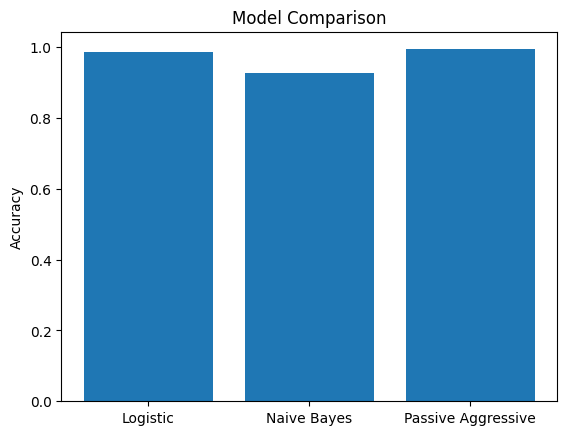

In [56]:
models = ["Logistic", "Naive Bayes", "Passive Aggressive"]
scores = [
    accuracy_score(y_test, model.predict(X_test)),
    accuracy_score(y_test, nb.predict(X_test)),
    accuracy_score(y_test, pa.predict(X_test))
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()